In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

# Project paths
DATA_DIR = Path("../data/processed")
RAW_DIR = Path("../data/raw")
CHART_DIR = Path("../reports/eda_charts")

# Create chart output folder
CHART_DIR.mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("EDA environment ready.")
print("Processed data:", DATA_DIR)
print("Chart output:", CHART_DIR)

EDA environment ready.
Processed data: ..\data\processed
Chart output: ..\reports\eda_charts


In [52]:
# Load cleaned datasets

nav = pd.read_csv(DATA_DIR / "nav_history_cleaned.csv")
fund_master = pd.read_csv(DATA_DIR / "fund_master_cleaned.csv")
transactions = pd.read_csv(DATA_DIR / "investor_transactions_cleaned.csv")
aum = pd.read_csv(DATA_DIR / "aum_by_fund_house_cleaned.csv")
sip = pd.read_csv(DATA_DIR / "monthly_sip_inflows_cleaned.csv")
category_inflows = pd.read_csv(DATA_DIR / "category_inflows_cleaned.csv")
folios = pd.read_csv(DATA_DIR / "industry_folio_count_cleaned.csv")
portfolio = pd.read_csv(DATA_DIR / "portfolio_holdings_cleaned.csv")

# Convert date columns
nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
aum["date"] = pd.to_datetime(aum["date"])
sip["month"] = pd.to_datetime(sip["month"])
category_inflows["month"] = pd.to_datetime(category_inflows["month"])
folios["month"] = pd.to_datetime(folios["month"])
portfolio["portfolio_date"] = pd.to_datetime(portfolio["portfolio_date"])

print("NAV:", nav.shape)
print("Fund Master:", fund_master.shape)
print("Transactions:", transactions.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category Inflows:", category_inflows.shape)
print("Folios:", folios.shape)
print("Portfolio:", portfolio.shape)

NAV: (46000, 3)
Fund Master: (40, 15)
Transactions: (32778, 13)
AUM: (90, 5)
SIP: (48, 6)
Category Inflows: (144, 3)
Folios: (21, 6)
Portfolio: (322, 8)


## 1. NAV Trend Analysis

Daily NAV trends for all 40 mutual fund schemes from 2022 to 2026 are analyzed using Plotly. The visualization helps identify broad market trends, the 2023 bull run, and market corrections during 2024.

In [53]:
# NAV Trend Analysis — all 40 schemes

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend — All 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "AMFI Code"
    }
)

# Highlight 2023 period
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.08,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 correction period
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.05,
    line_width=0,
    annotation_text="2024 Market Period",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    height=700
)

fig.show()
fig.write_image(
    CHART_DIR / "nav_trend_all_40.png",
    width=1400,
    height=800
)

print("NAV chart exported.")

NAV chart exported.


In [54]:
fig.write_html(CHART_DIR / "nav_trend_all_40.html")

print("Saved:", CHART_DIR / "nav_trend_all_40.html")

Saved: ..\reports\eda_charts\nav_trend_all_40.html


## 2. AUM Growth by Fund House

Annual AUM growth is compared across fund houses from 2022 to 2025 using a grouped bar chart. This analysis highlights changes in assets under management and identifies the leading fund houses by AUM.

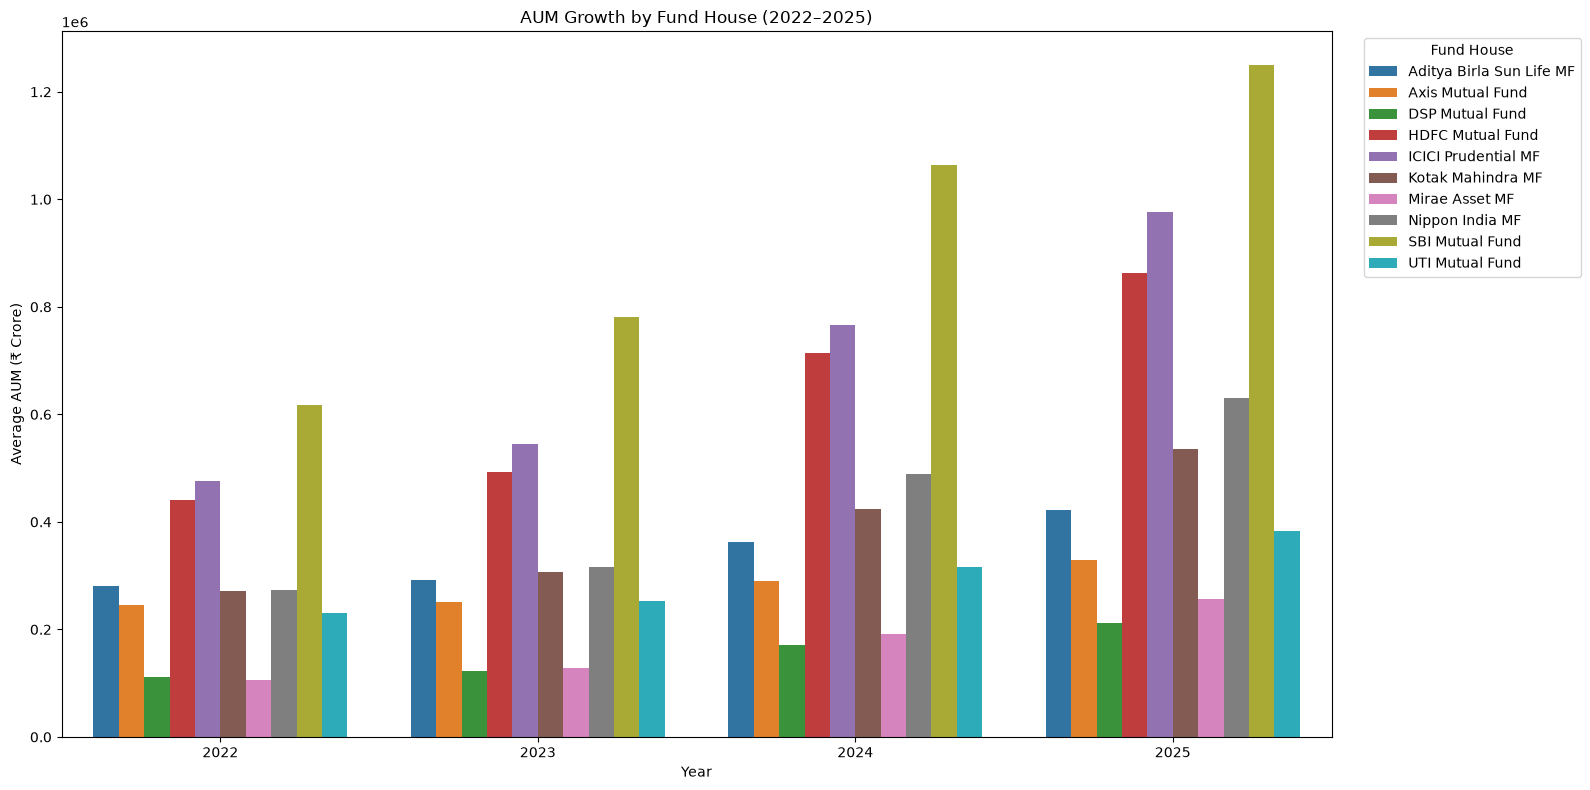

In [55]:
# AUM Growth by Fund House — 2022 to 2025

aum["year"] = aum["date"].dt.year

aum_yearly = (
    aum[aum["year"].between(2022, 2025)]
    .groupby(["year", "fund_house"], as_index=False)["aum_crore"]
    .mean()
)

plt.figure(figsize=(16, 8))

sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Average AUM (₹ Crore)")
plt.legend(title="Fund House", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "aum_growth_by_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
# Check SBI AUM values

sbi_aum = aum[
    aum["fund_house"].str.contains("SBI", case=False, na=False)
].copy()

print(sbi_aum[["date", "aum_crore"]].sort_values("date").tail(10))

         date  aum_crore
0  2022-03-31     605000
10 2022-09-30     630000
20 2023-03-31     717000
30 2023-09-30     845000
40 2024-03-31    1000000
50 2024-09-30    1080000
60 2024-12-31    1114000
70 2025-03-31    1250000
80 2025-12-31    1250000


In [57]:
# Highlight SBI's ₹12.5 lakh crore AUM dominance

sbi_peak = sbi_aum.loc[sbi_aum["aum_crore"].idxmax()]

print(
    f"SBI peak AUM: ₹{sbi_peak['aum_crore'] / 100000:.2f} lakh crore "
    f"on {sbi_peak['date'].date()}"
)

SBI peak AUM: ₹12.50 lakh crore on 2025-03-31


## 3. SIP Inflow Time-Series

Monthly SIP inflows from January 2022 to December 2025 are analyzed using Plotly. The chart highlights the all-time high SIP inflow and shows the overall growth trend.

In [58]:
# SIP Inflow Time-Series — Jan 2022 to Dec 2025

sip_trend = sip[
    (sip["month"] >= "2022-01-01") &
    (sip["month"] <= "2025-12-31")
].copy()

fig = px.line(
    sip_trend,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Find actual maximum from dataset
peak_idx = sip_trend["sip_inflow_crore"].idxmax()
peak_row = sip_trend.loc[peak_idx]

fig.add_annotation(
    x=peak_row["month"],
    y=peak_row["sip_inflow_crore"],
    text=f"Peak: ₹{peak_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    template="plotly_white",
    height=600,
    hovermode="x unified"
)

fig.show()
fig.write_image(
    CHART_DIR / "sip_inflow_trend.png",
    width=1400,
    height=800
)

print("SIP chart exported.")

SIP chart exported.


## 4. Category Inflow Heatmap

Monthly net inflows are compared across mutual fund categories using a heatmap. This visualization highlights periods and categories with relatively high or low net inflows.

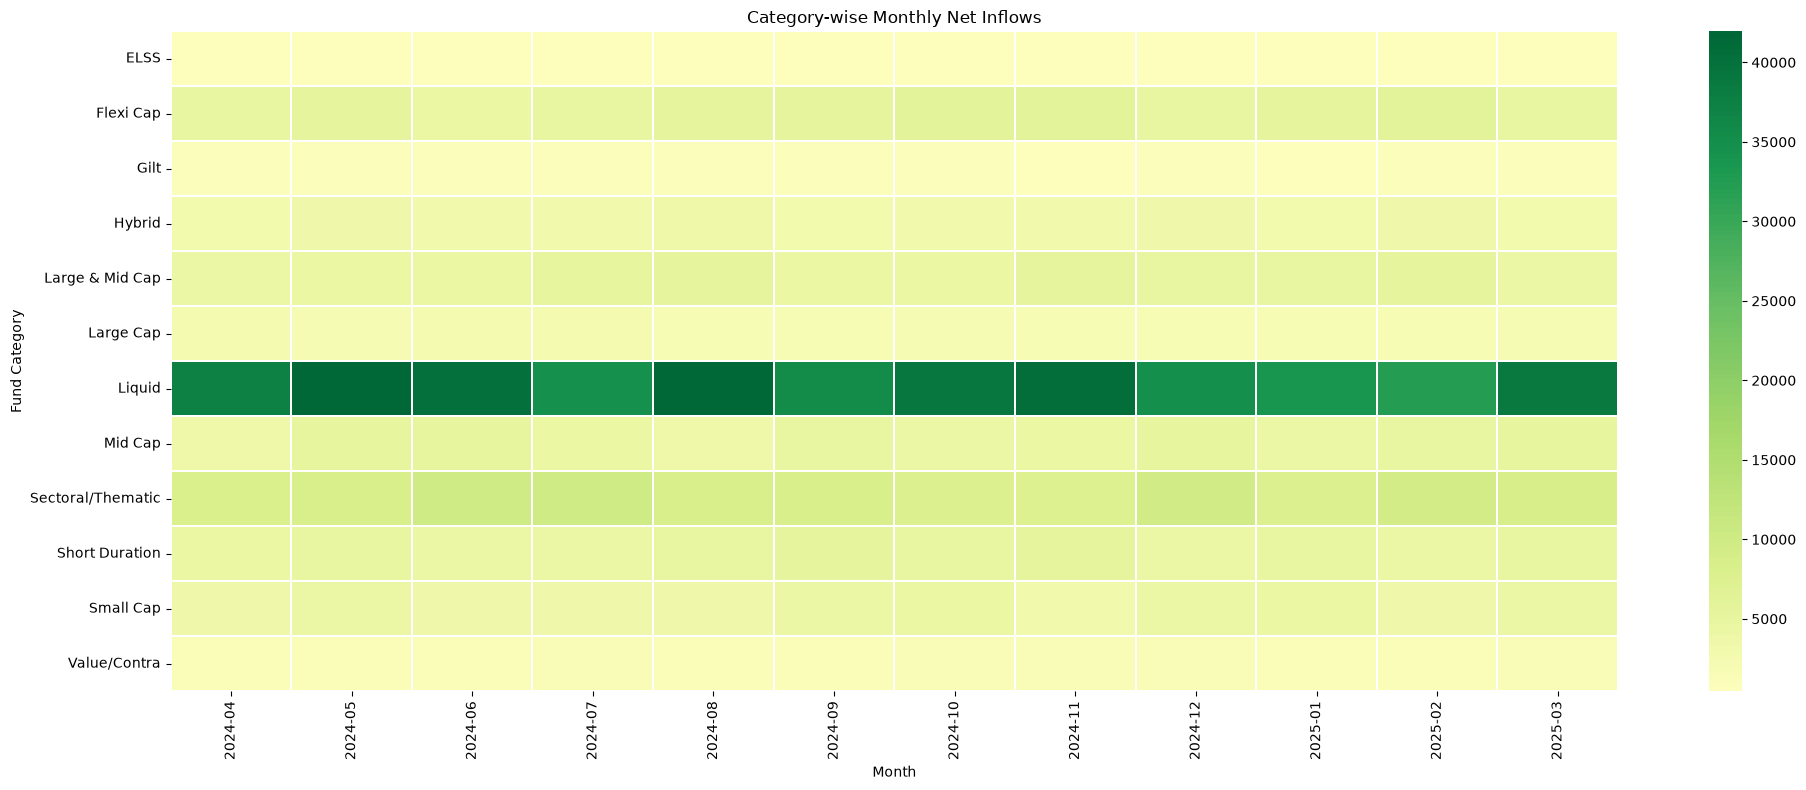

In [59]:
# Category Inflow Heatmap

category_pivot = category_inflows.pivot_table(
    index="category",
    columns=category_inflows["month"].dt.strftime("%Y-%m"),
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(20, 8))

sns.heatmap(
    category_pivot,
    cmap="RdYlGn",
    center=0,
    annot=False,
    linewidths=0.3
)

plt.title("Category-wise Monthly Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    CHART_DIR / "category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Investor Demographics

Investor demographics are analyzed using age-group distribution, SIP transaction amounts across age groups, and gender distribution to understand the characteristics of investors in the dataset.

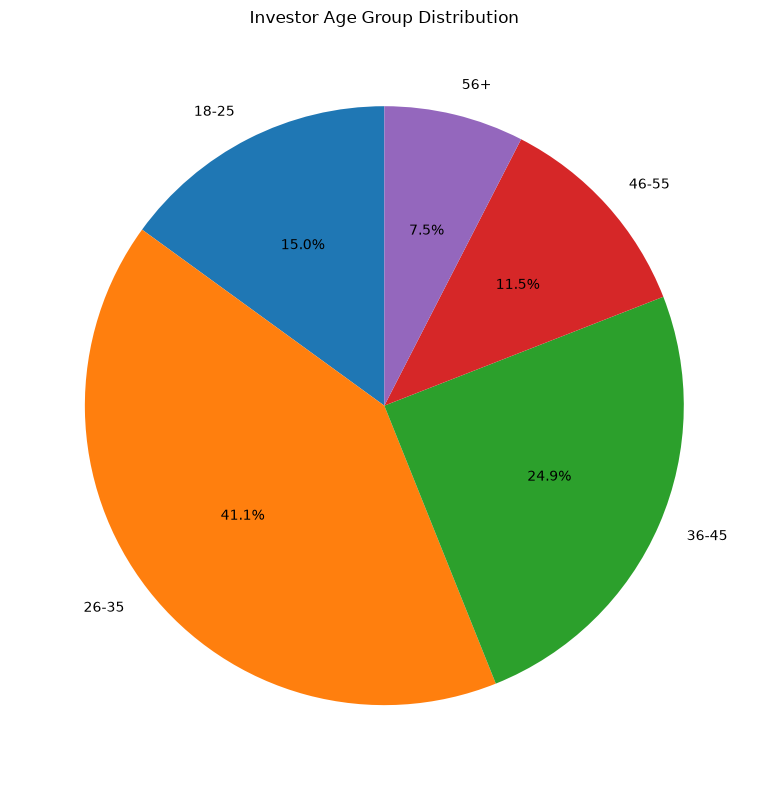

In [60]:
# Age Group Distribution

age_counts = transactions["age_group"].value_counts().sort_index()

plt.figure(figsize=(8, 8))

plt.pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "investor_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

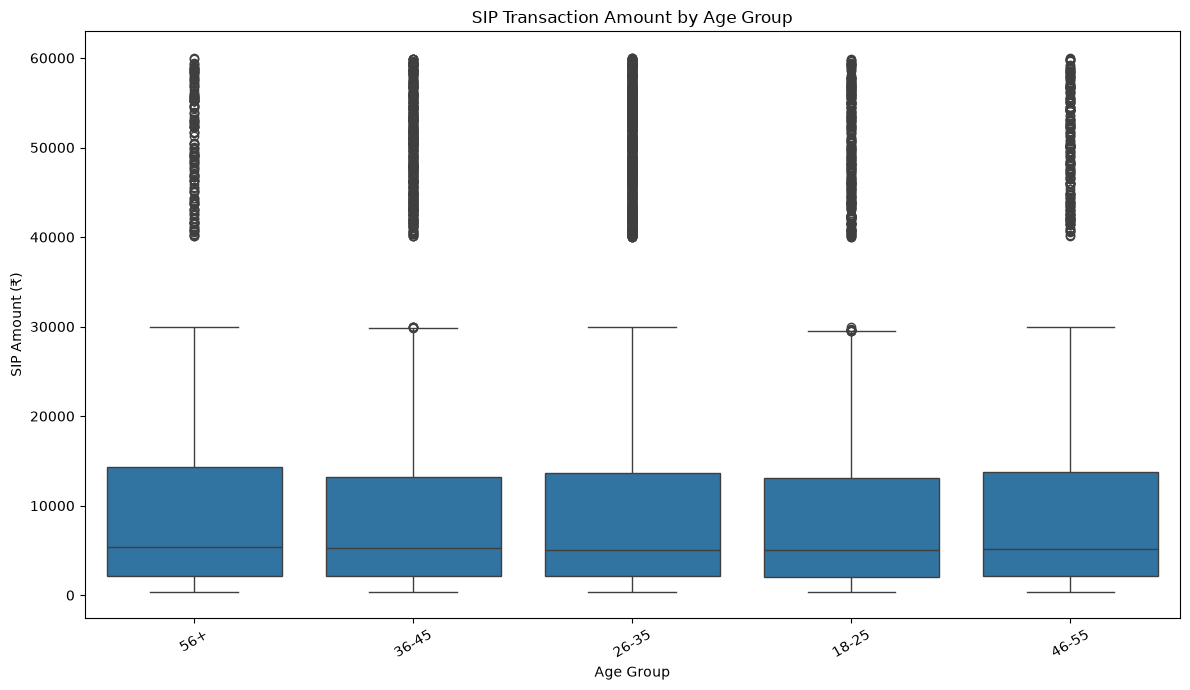

In [61]:
# SIP Amount by Age Group — Box Plot

sip_transactions = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Transaction Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    CHART_DIR / "sip_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

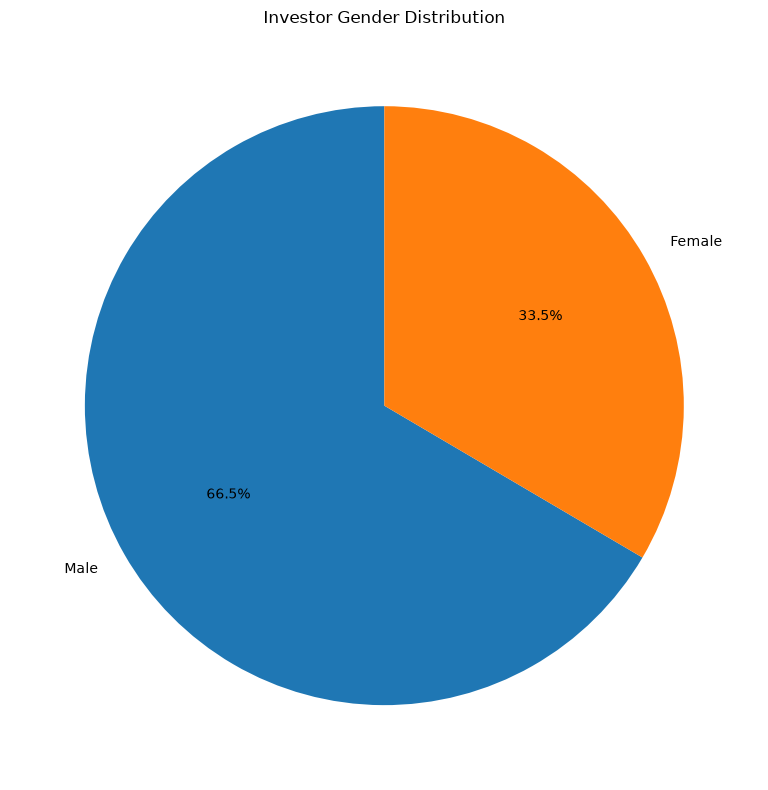

In [62]:
# Gender Distribution

gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "investor_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Geographic Distribution

The geographic distribution of SIP investments is analyzed by state and city tier. The analysis identifies states with higher SIP transaction amounts and compares investments from T30 and B30 cities.

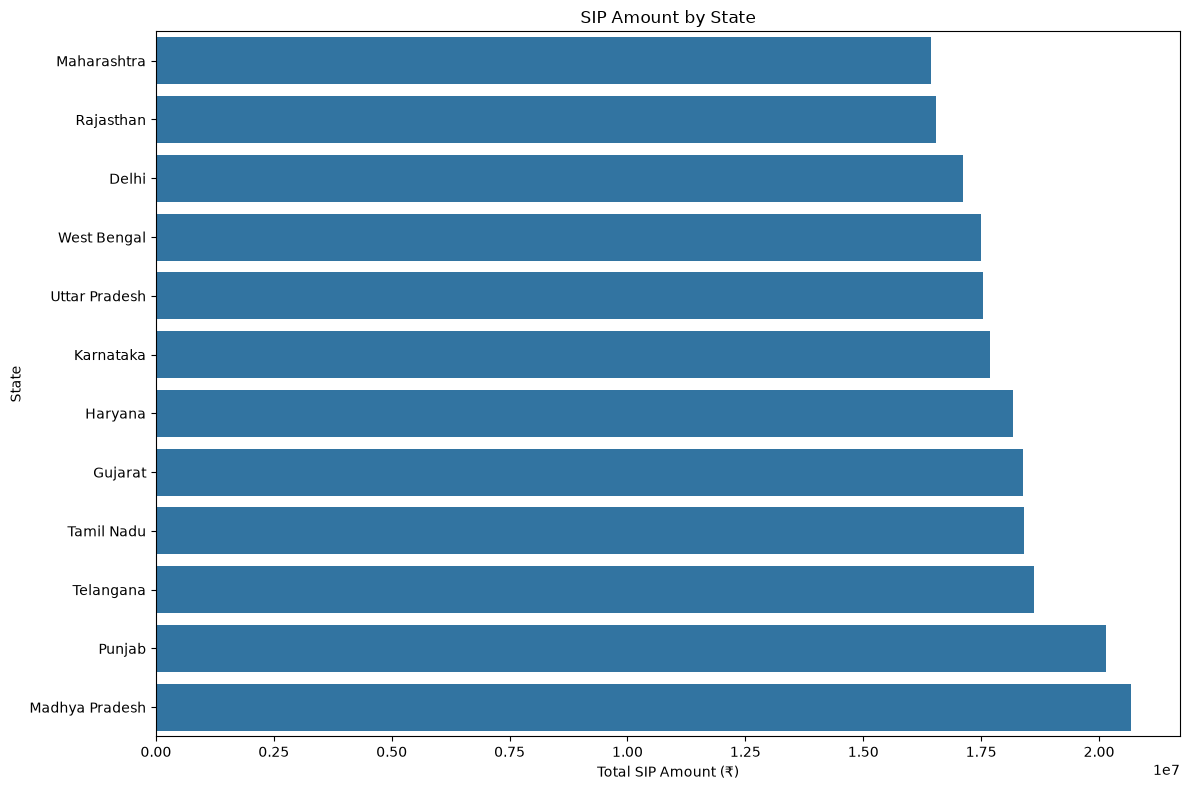

In [63]:
# SIP Amount by State

sip_state = (
    sip_transactions
    .groupby("state", as_index=False)["amount_inr"]
    .sum()
    .sort_values("amount_inr", ascending=True)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=sip_state,
    x="amount_inr",
    y="state"
)

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "sip_amount_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

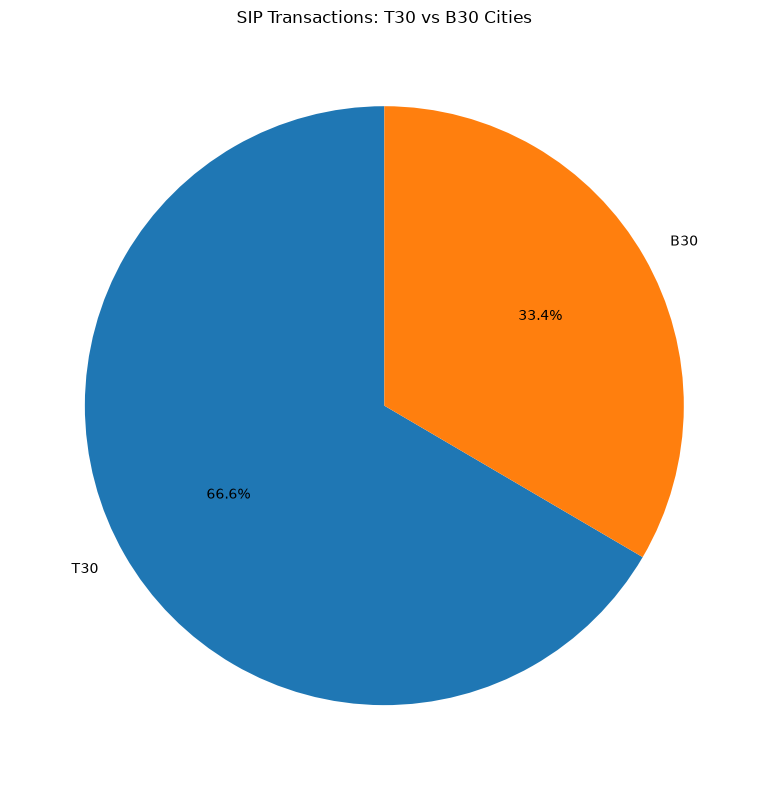

In [64]:
# T30 vs B30 City Tier Distribution

tier_counts = sip_transactions["city_tier"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("SIP Transactions: T30 vs B30 Cities")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "t30_vs_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Folio Count Growth

The growth in total mutual fund folios is analyzed from January 2022 to December 2025. Key milestones are marked to show the expansion of the investor base over time.

In [65]:
# Folio Count Growth

folio_trend = folios.sort_values("month").copy()

fig = px.line(
    folio_trend,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Folio Count Growth (2022–2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    }
)

# Mark starting value
start_row = folio_trend.iloc[0]

fig.add_annotation(
    x=start_row["month"],
    y=start_row["total_folios_crore"],
    text=f"Start: {start_row['total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2
)

# Mark ending value
end_row = folio_trend.iloc[-1]

fig.add_annotation(
    x=end_row["month"],
    y=end_row["total_folios_crore"],
    text=f"End: {end_row['total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    template="plotly_white",
    height=600,
    hovermode="x unified"
)

fig.show()

In [66]:
fig.write_html(CHART_DIR / "folio_count_growth.html")

print(
    f"Starting folios: {start_row['total_folios_crore']:.2f} Cr "
    f"({start_row['month'].strftime('%b %Y')})"
)

print(
    f"Ending folios: {end_row['total_folios_crore']:.2f} Cr "
    f"({end_row['month'].strftime('%b %Y')})"
)

print("Saved:", CHART_DIR / "folio_count_growth.html")

Starting folios: 13.26 Cr (Jan 2022)
Ending folios: 26.12 Cr (Dec 2025)
Saved: ..\reports\eda_charts\folio_count_growth.html


## 8. NAV Return Correlation Matrix

The pairwise correlation of daily NAV returns is calculated for 10 selected mutual fund schemes. The heatmap helps identify funds whose returns tend to move together or differently.

In [67]:
# Select 10 funds

selected_funds = nav["amfi_code"].drop_duplicates().head(10).tolist()

nav_selected = nav[
    nav["amfi_code"].isin(selected_funds)
].copy()

# Calculate daily returns for each fund
nav_selected = nav_selected.sort_values(["amfi_code", "date"])

nav_selected["daily_return"] = (
    nav_selected.groupby("amfi_code")["nav"].pct_change()
)

# Convert to wide format
returns_wide = nav_selected.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

# Correlation matrix
correlation_matrix = returns_wide.corr()

print("Selected AMFI Codes:")
print(selected_funds)

print("\nCorrelation Matrix:")
display(correlation_matrix.round(3))

Selected AMFI Codes:
[100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886, 102887, 118632]

Correlation Matrix:


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000,0.046,-0.000,0.028,0.016,-0.034,-0.094,-0.006,-0.023,-0.027
100025,0.046,1.000,0.002,0.024,-0.007,0.018,-0.001,0.014,-0.006,-0.014
100033,-0.000,0.002,1.000,-0.018,0.000,0.008,-0.034,-0.018,-0.037,-0.013
101206,0.028,0.024,-0.018,1.000,0.010,-0.027,0.002,0.007,-0.006,-0.005
101207,0.016,-0.007,0.000,0.010,1.000,-0.008,-0.006,0.005,0.002,0.043
101208,-0.034,0.018,0.008,-0.027,-0.008,1.000,-0.001,0.014,0.037,0.004
102885,-0.094,-0.001,-0.034,0.002,-0.006,-0.001,1.000,0.021,-0.037,-0.000
102886,-0.006,0.014,-0.018,0.007,0.005,0.014,0.021,1.000,-0.008,-0.040
102887,-0.023,-0.006,-0.037,-0.006,0.002,0.037,-0.037,-0.008,1.000,0.001


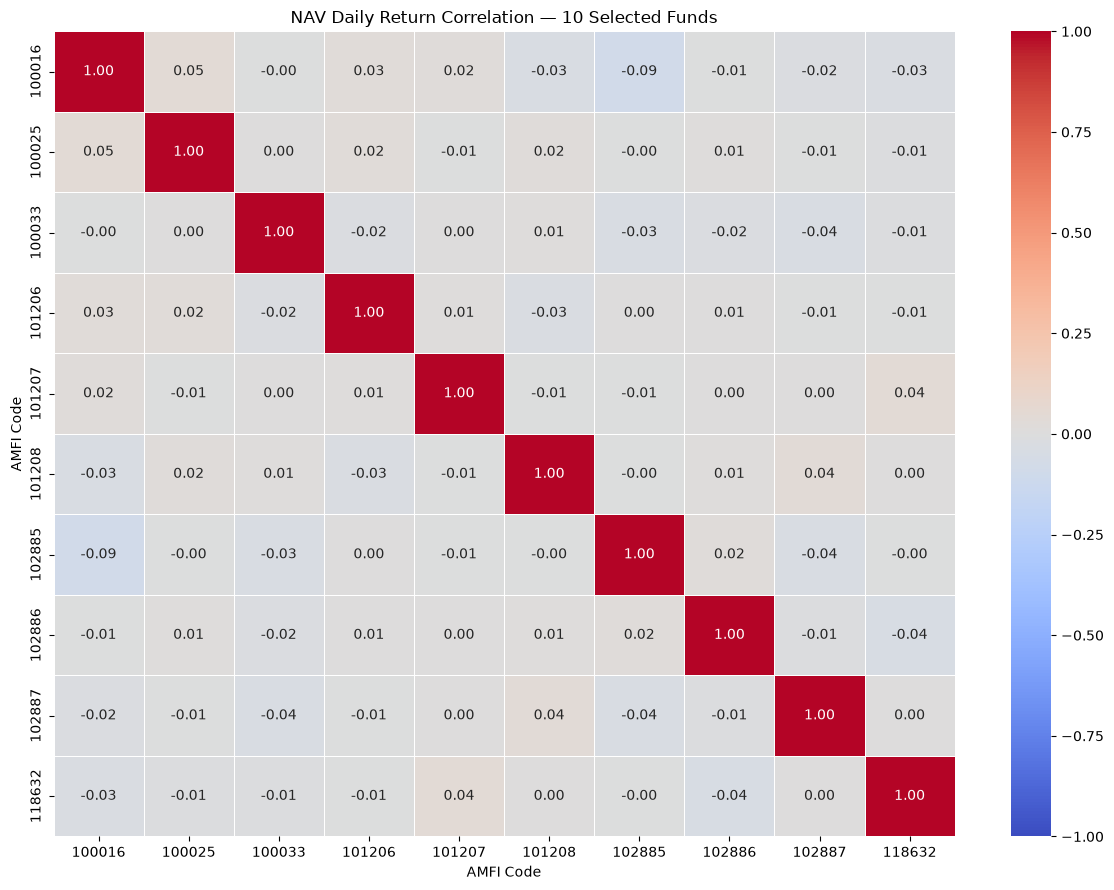

In [68]:
# NAV Return Correlation Heatmap

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("NAV Daily Return Correlation — 10 Selected Funds")
plt.xlabel("AMFI Code")
plt.ylabel("AMFI Code")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "nav_return_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Sector Allocation

Sector weights are aggregated across the portfolio holdings dataset to show the overall sector allocation. A donut chart is used to visualize the relative contribution of each sector.

In [69]:
# Aggregate sector weights

sector_allocation = (
    portfolio
    .groupby("sector", as_index=False)["weight_pct"]
    .sum()
    .sort_values("weight_pct", ascending=False)
)

print("Sector Allocation:")
display(sector_allocation)

Sector Allocation:


,sector,weight_pct
1,Banking,652.26
7,IT,455.47
11,Pharma,407.45
0,Automobile,323.65
13,Utilities,265.54
6,FMCG,229.11
8,Infrastructure,192.16
4,Diversified,169.23
12,Telecom,145.62
3,Consumer Goods,127.61


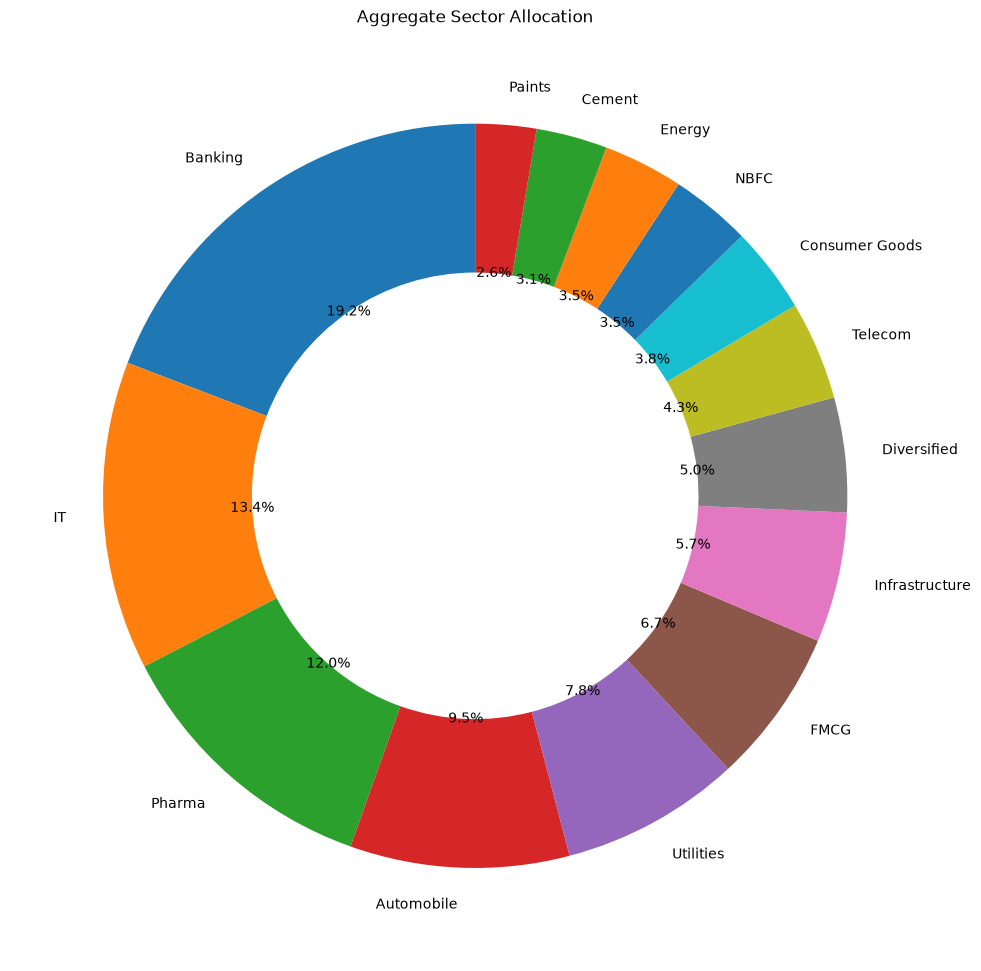

In [70]:
# Sector Allocation Donut Chart

plt.figure(figsize=(10, 10))

plt.pie(
    sector_allocation["weight_pct"],
    labels=sector_allocation["sector"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Aggregate Sector Allocation")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 10. Key EDA Findings

### Finding 1 — NAV Trends
The NAV trend analysis shows how the 40 schemes evolved between 2022 and 2026, with broad market movements visible during the 2023 growth period and subsequent 2024 market fluctuations.  
**Chart reference:** `nav_trend_all_40.html`

### Finding 2 — AUM Growth
SBI shows the highest AUM in the dataset, reaching ₹12.5 lakh crore in 2025, demonstrating its dominance among the fund houses analyzed.  
**Chart reference:** `aum_growth_by_fund_house.png`

### Finding 3 — SIP Inflows
Monthly SIP inflows increased substantially over the analysis period and reached an all-time high of ₹31,002 crore in December 2025.  
**Chart reference:** `sip_inflow_trend.html`

### Finding 4 — Category Inflows
The category heatmap shows that net inflows vary considerably across categories and months, indicating changing investor preferences over time.  
**Chart reference:** `category_inflow_heatmap.png`

### Finding 5 — Investor Age Groups
The investor age-group distribution shows the relative participation of different age segments in the transaction dataset.  
**Chart reference:** `investor_age_distribution.png`

### Finding 6 — SIP Amount by Age
The SIP amount box plot demonstrates differences in transaction amount distributions across investor age groups.  
**Chart reference:** `sip_amount_by_age_group.png`

### Finding 7 — Geographic Distribution
SIP investment amounts differ substantially across states, indicating that investor participation is geographically concentrated in some regions.  
**Chart reference:** `sip_amount_by_state.png`

### Finding 8 — Folio Growth
The total number of mutual fund folios increased from approximately 13.26 crore in January 2022 to 26.12 crore in December 2025, indicating strong expansion in the investor base.  
**Chart reference:** `folio_count_growth.html`

### Finding 9 — Return Correlation
The correlation heatmap shows varying relationships between the daily returns of the selected funds, with some funds exhibiting stronger co-movement than others.  
**Chart reference:** `nav_return_correlation_heatmap.png`

### Finding 10 — Sector Allocation
The aggregate sector allocation demonstrates how portfolio holdings are distributed across different sectors, highlighting the sectors with the largest combined portfolio weights.  
**Chart reference:** `sector_allocation_donut.png`

## Additional EDA — Total Net Inflow by Category

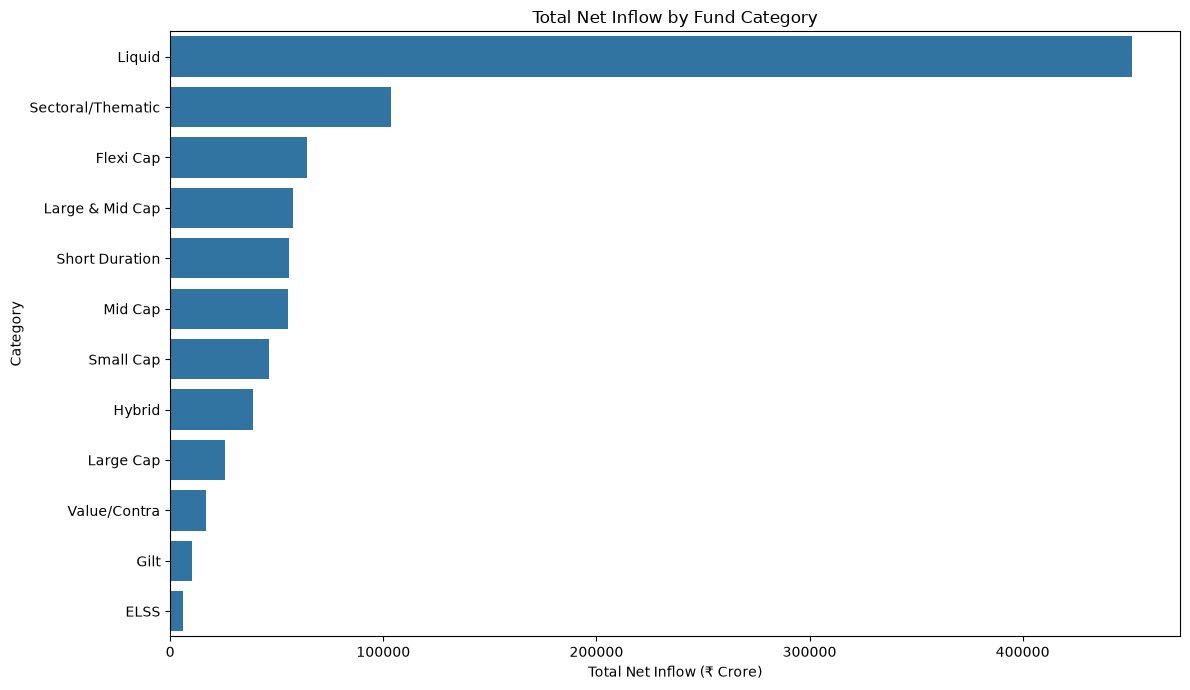

In [71]:
# Total Net Inflow by Category

category_total = (
    category_inflows
    .groupby("category", as_index=False)["net_inflow_crore"]
    .sum()
    .sort_values("net_inflow_crore", ascending=False)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=category_total,
    x="net_inflow_crore",
    y="category"
)

plt.title("Total Net Inflow by Fund Category")
plt.xlabel("Total Net Inflow (₹ Crore)")
plt.ylabel("Category")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "total_inflow_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

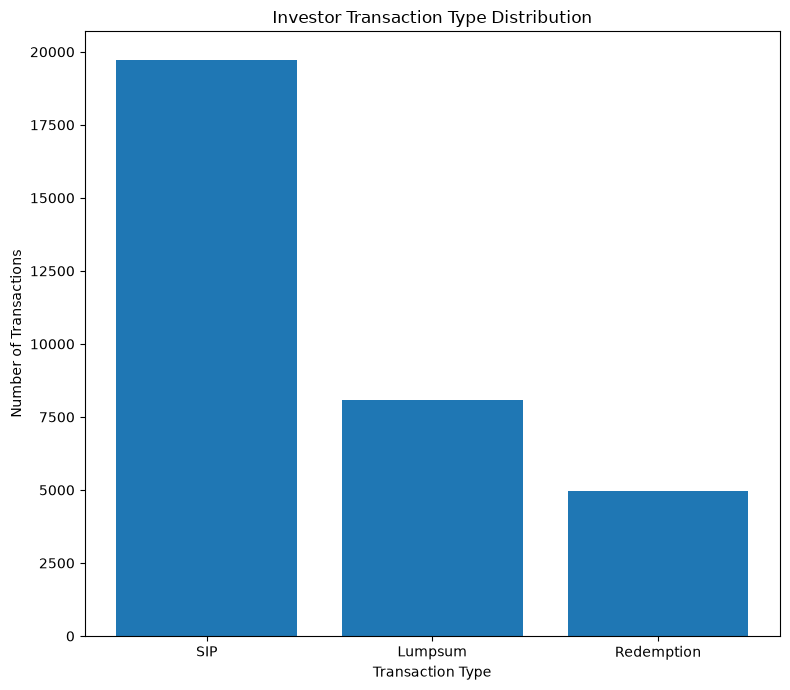

In [72]:
# Transaction Type Distribution

transaction_counts = transactions["transaction_type"].value_counts()

plt.figure(figsize=(8, 7))

plt.bar(
    transaction_counts.index,
    transaction_counts.values
)

plt.title("Investor Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "transaction_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

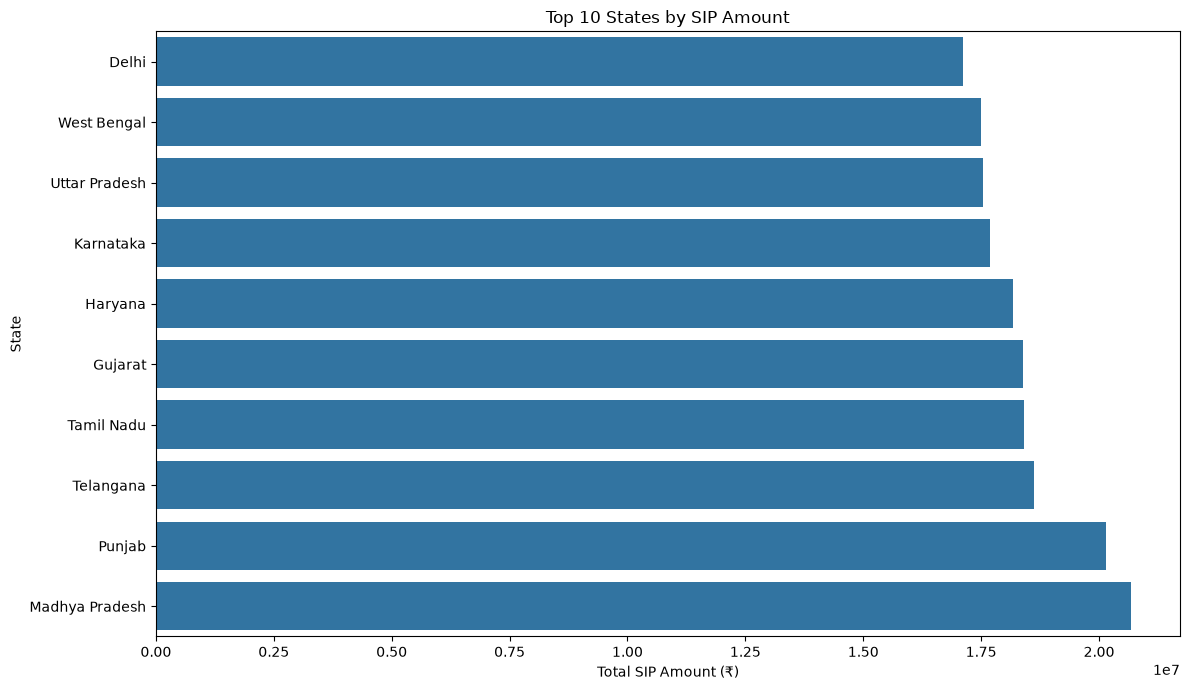

In [73]:
# Top 10 States by SIP Amount

top_states = (
    sip_transactions
    .groupby("state", as_index=False)["amount_inr"]
    .sum()
    .sort_values("amount_inr", ascending=False)
    .head(10)
    .sort_values("amount_inr", ascending=True)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_states,
    x="amount_inr",
    y="state"
)

plt.title("Top 10 States by SIP Amount")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "top_10_states_sip.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

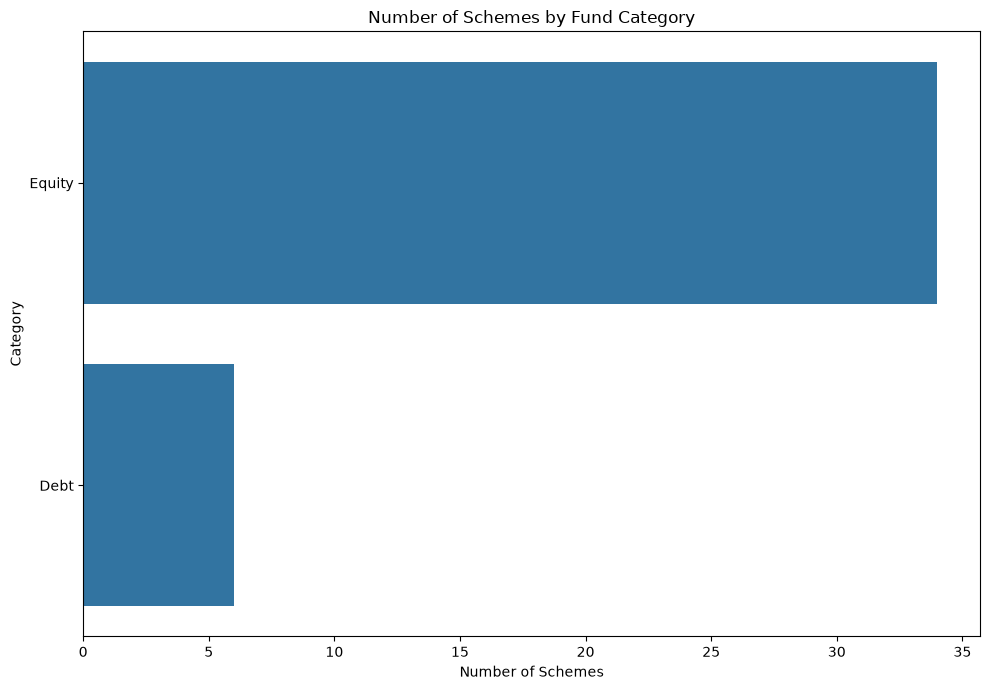

In [74]:
# Fund Category Distribution

fund_category_counts = fund_master["category"].value_counts()

plt.figure(figsize=(10, 7))

sns.barplot(
    x=fund_category_counts.values,
    y=fund_category_counts.index
)

plt.title("Number of Schemes by Fund Category")
plt.xlabel("Number of Schemes")
plt.ylabel("Category")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "fund_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [75]:
# Export Plotly charts as PNG for the final report

fig.write_image(
    CHART_DIR / "folio_count_growth.png",
    width=1400,
    height=800
)

print("Folio chart exported.")

Folio chart exported.
